In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


In [1]:
import os
print(os.listdir())


['.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'learn flu', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{1bf12db1-b527-11f0-8135-a059503b2b9d}.TM.blf', 'NTUSER.DAT{1bf12db1-b527-11f0-8135-a059503b2b9d}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{1bf12db1-b527-11f0-8135-a059503b2b9d}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'supply_chain_project.ipynb', 'Templates', 'Untitled.ipynb', 'Videos']


In [4]:
import pandas as pd

data = pd.read_csv("supply_chain_data.csv")
data.head()


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [5]:
# Basic info about dataset
data.info()

# Check missing values
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [6]:
data = data.dropna()
data.isnull().sum()


Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [7]:
# Check first few rows again
data.head()

# Check numeric summaries
data.describe()

# Check all unique categories in each column
for col in data.select_dtypes(include='object').columns:
    print(f"{col}: {data[col].nunique()} unique values")


Product type: 3 unique values
SKU: 100 unique values
Customer demographics: 4 unique values
Shipping carriers: 3 unique values
Supplier name: 5 unique values
Location: 5 unique values
Inspection results: 3 unique values
Transportation modes: 4 unique values
Routes: 3 unique values


In [8]:
data.groupby('Product type')['Revenue generated'].sum().sort_values(ascending=False)


Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64

In [9]:
data.groupby('Supplier name')['Lead time'].mean().sort_values()


Supplier name
Supplier 1    14.777778
Supplier 4    15.222222
Supplier 5    18.055556
Supplier 2    18.545455
Supplier 3    20.133333
Name: Lead time, dtype: float64

In [11]:
data.columns


Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [14]:
data['Profit'] = data['Revenue generated'] - (data['Manufacturing costs'] + data['Costs'])
data.head()


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,Profit
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,8427.964838
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,6924.217717
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282,9405.141325
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,7476.435525
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,1670.999359


In [15]:
data[['Product type', 'Revenue generated', 'Manufacturing costs', 'Costs', 'Profit']].head()


,Product type,Revenue generated,Manufacturing costs,Costs,Profit
0,haircare,8661.996792,46.279879,187.752075,8427.964838
1,skincare,7460.900065,33.616769,503.065579,6924.217717
2,haircare,9577.749626,30.688019,141.920282,9405.141325
3,skincare,7766.836426,35.624741,254.776159,7476.435525
4,skincare,2686.505152,92.065161,923.440632,1670.999359


In [16]:
data.groupby('Product type')['Profit'].sum().sort_values(ascending=False)


Product type
skincare     217439.117770
haircare     155478.955964
cosmetics    147035.497463
Name: Profit, dtype: float64

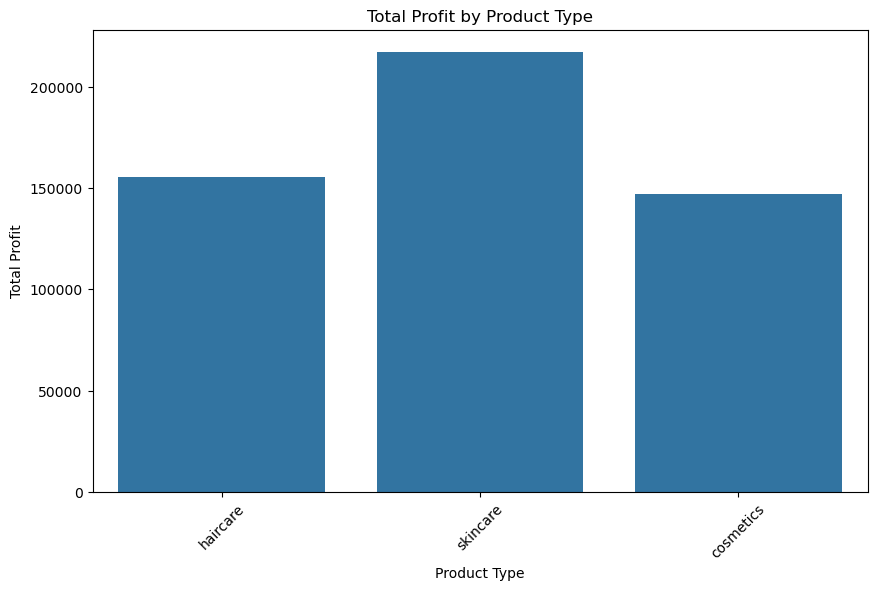

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Product type', y='Profit', data=data, estimator=sum, errorbar=None)
plt.title('Total Profit by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()


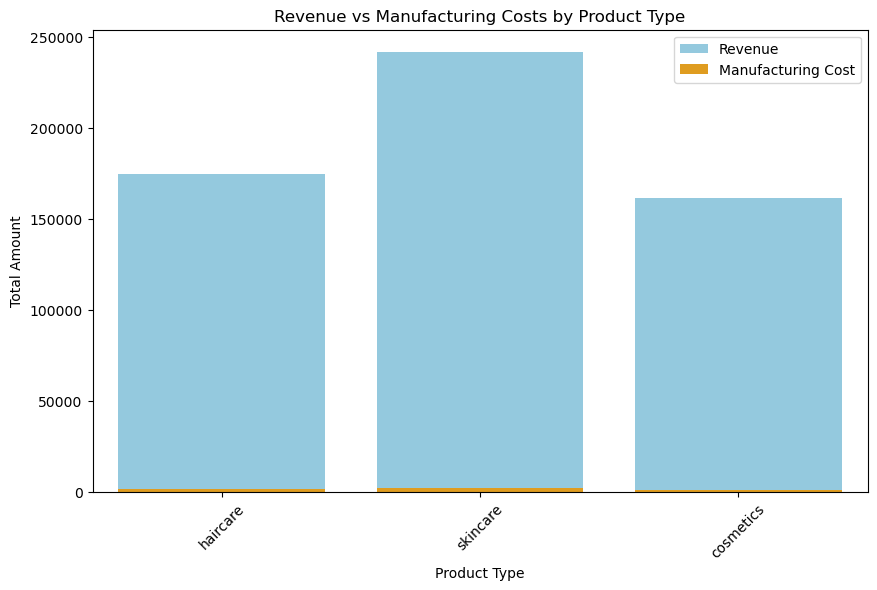

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x='Product type', y='Revenue generated', data=data, estimator=sum, color='skyblue', label='Revenue', errorbar=None)
sns.barplot(x='Product type', y='Manufacturing costs', data=data, estimator=sum, color='orange', label='Manufacturing Cost', errorbar=None)
plt.legend()
plt.title('Revenue vs Manufacturing Costs by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()


In [20]:
supplier_profit = data.groupby('Supplier name')['Profit'].sum().sort_values(ascending=False)
print(supplier_profit.head(10))


Supplier name
Supplier 1    140786.155560
Supplier 2    113221.123995
Supplier 5     99889.226150
Supplier 3     90109.466295
Supplier 4     75947.599198
Name: Profit, dtype: float64


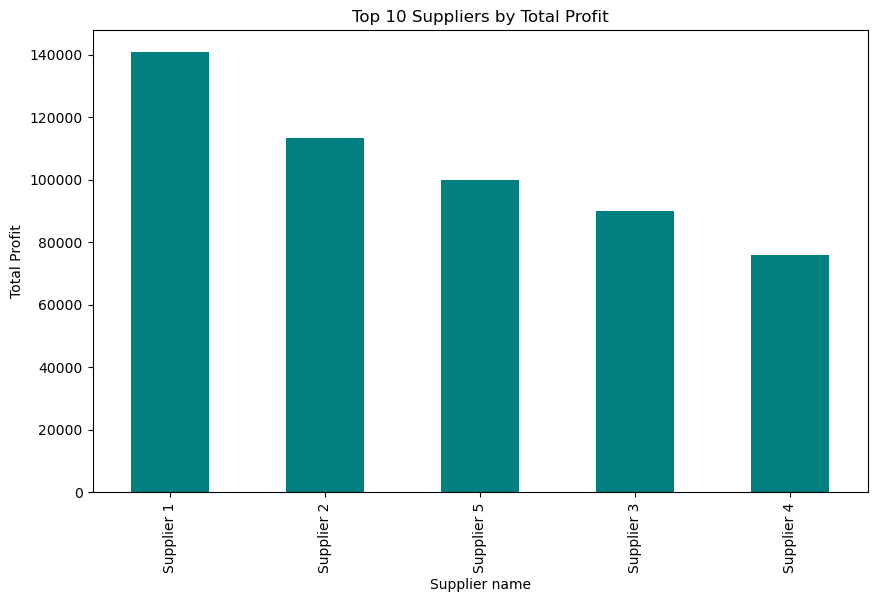

In [21]:
plt.figure(figsize=(10,6))
supplier_profit.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Suppliers by Total Profit')
plt.ylabel('Total Profit')
plt.show()


In [22]:
data.groupby('Shipping carriers')['Shipping costs'].mean().sort_values(ascending=False)


Shipping carriers
Carrier C    5.599292
Carrier A    5.554923
Carrier B    5.509247
Name: Shipping costs, dtype: float64

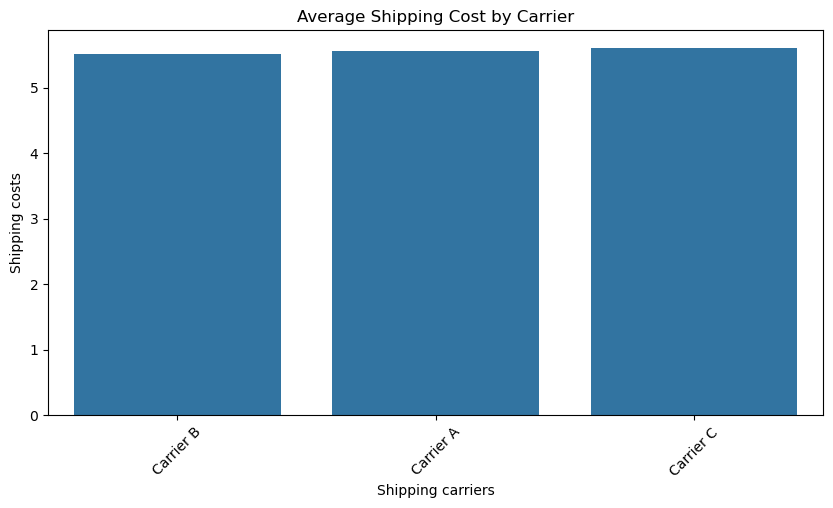

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(x='Shipping carriers', y='Shipping costs', data=data, estimator='mean', errorbar=None)
plt.title('Average Shipping Cost by Carrier')
plt.xticks(rotation=45)
plt.show()


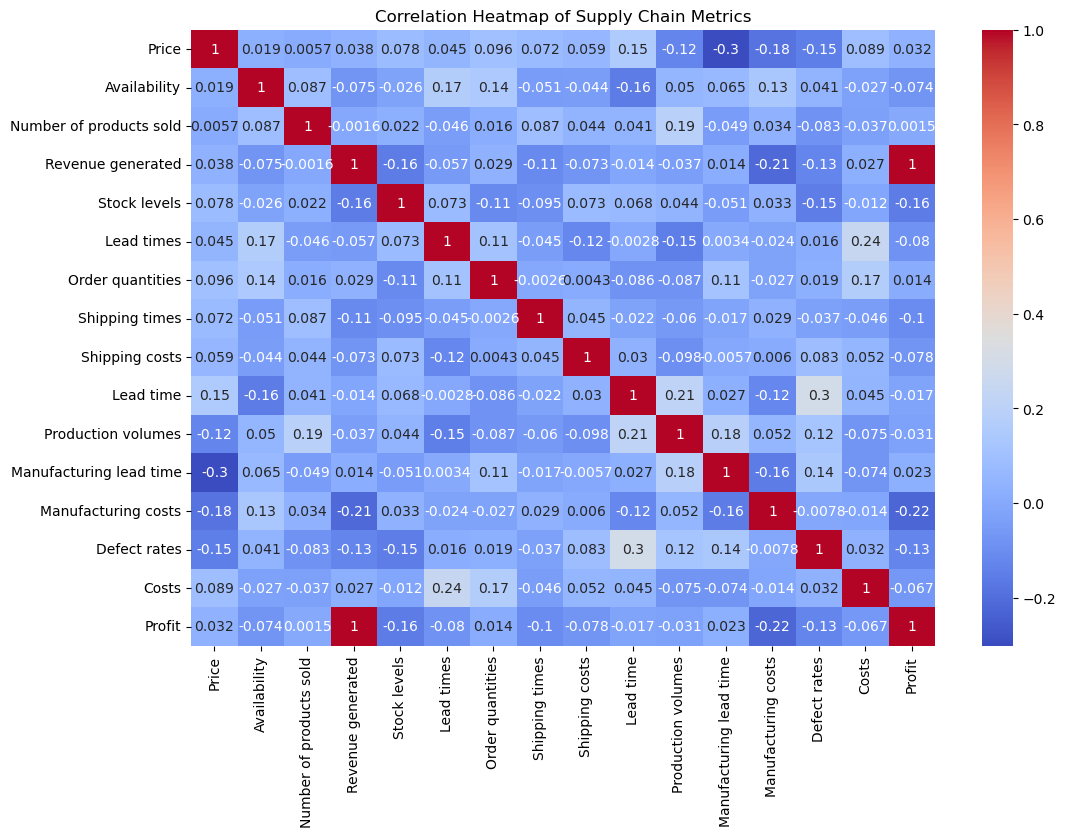

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Supply Chain Metrics')
plt.show()


In [25]:
data.to_csv("final_supply_chain_analysis.csv", index=False)
print("✅ Final analyzed dataset saved successfully!")


✅ Final analyzed dataset saved successfully!
